# vbOCP — Test 1: pipeline completa

Notebook orchestratore bash-style: le celle di codice lanciano solo comandi verso gli script della repo — nessuna logica del modello qui dentro. Stesso pattern per Colab/cluster: cambia solo dove lo lanci.

**Contenuto:**
1. Setup (path della repo)
2. FOM — solve singolo + plot, generazione snapshot
3. ROM (POD) — training + plot decadimento autovalori
4. GNN — gca-rom: solo y, solo p, combinato
5. Autoencoder *(da aggiungere)*

## 0. Setup Colab (installazione + clone repo)

Copia di `run_pipeline.ipynb` pensata per girare su un kernel Colab, dove il filesystem locale non e' visibile - la repo va clonata da GitHub a ogni sessione. La mesh usata da `configs/test1.yaml` e' inclusa nel repo (eccezione in `.gitignore`, ~1.5MB) cosi' non serve rigenerarla. Il resto del notebook e' identico all'originale (stesso pattern bash-style).

In [1]:
GITHUB_URL = 'https://github.com/roccnroll/vbOCP.git'
REPO_DIR = 'vbOCP'

!pip install -q pypolydim gmsh
!cd vbOCP && git pull
import os
if not os.path.isdir(REPO_DIR):
    !git clone {GITHUB_URL} {REPO_DIR}
else:
    print(f"{REPO_DIR} gia' presente (skip clone) - se vuoi aggiornarla: !cd {REPO_DIR} && git pull")

os.chdir(REPO_DIR)
print('cwd:', os.getcwd())

Already up to date.
vbOCP gia' presente (skip clone) - se vuoi aggiornarla: !cd vbOCP && git pull
cwd: /content/vbOCP


## 1. Setup

In [2]:
import os

# si sposta nella root della repo (dove c'e' src/), indipendentemente da dove parte il kernel
while not os.path.isdir('src') and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir('..')
assert os.path.isdir('src'), "src/ non trovata: verifica dove e' montata la repo vbOCP"

REPO_ROOT      = os.getcwd()
CONFIG_PATH    = os.path.join('configs', 'test1.yaml')
DATA_DIR       = os.path.join('data')
SNAPSHOTS_DIR  = os.path.join('data', 'snapshots')
OUTPUT_DIR     = os.path.join('notebooks', 'output')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SNAPSHOTS_DIR, exist_ok=True)

print('REPO_ROOT    :', REPO_ROOT)
print('CONFIG_PATH  :', CONFIG_PATH)
print('SNAPSHOTS_DIR:', SNAPSHOTS_DIR)

REPO_ROOT    : /content/vbOCP
CONFIG_PATH  : configs/test1.yaml
SNAPSHOTS_DIR: data/snapshots


## 2. FOM

### 2.1 Solve singolo + plot

Risolve il FOM per una terna di parametri e salva un confronto visivo di stato `y` e aggiunto `p`. Modifica `--mu1`/`--mu2`/`--mu_u` per esplorare altri punti dello spazio parametrico.

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Nh = 5306
Assembly operatori (indipendenti da mu) ...
Assembly matrice di controllo C(mu_u=0.5) ...
Solve OTD per mu1=12.0, mu2=2.5, mu_u=0.5 ...
Soluzione OTD:
  stato     y: min=1.0000, max=3.4809
  aggiunto  p: min=0.0001, max=0.3643
  controllo u: min=0.0019, max=5.2048
Plot salvato in /tmp/fom_solution.png
PLOT_PATH=/tmp/fom_solution.png


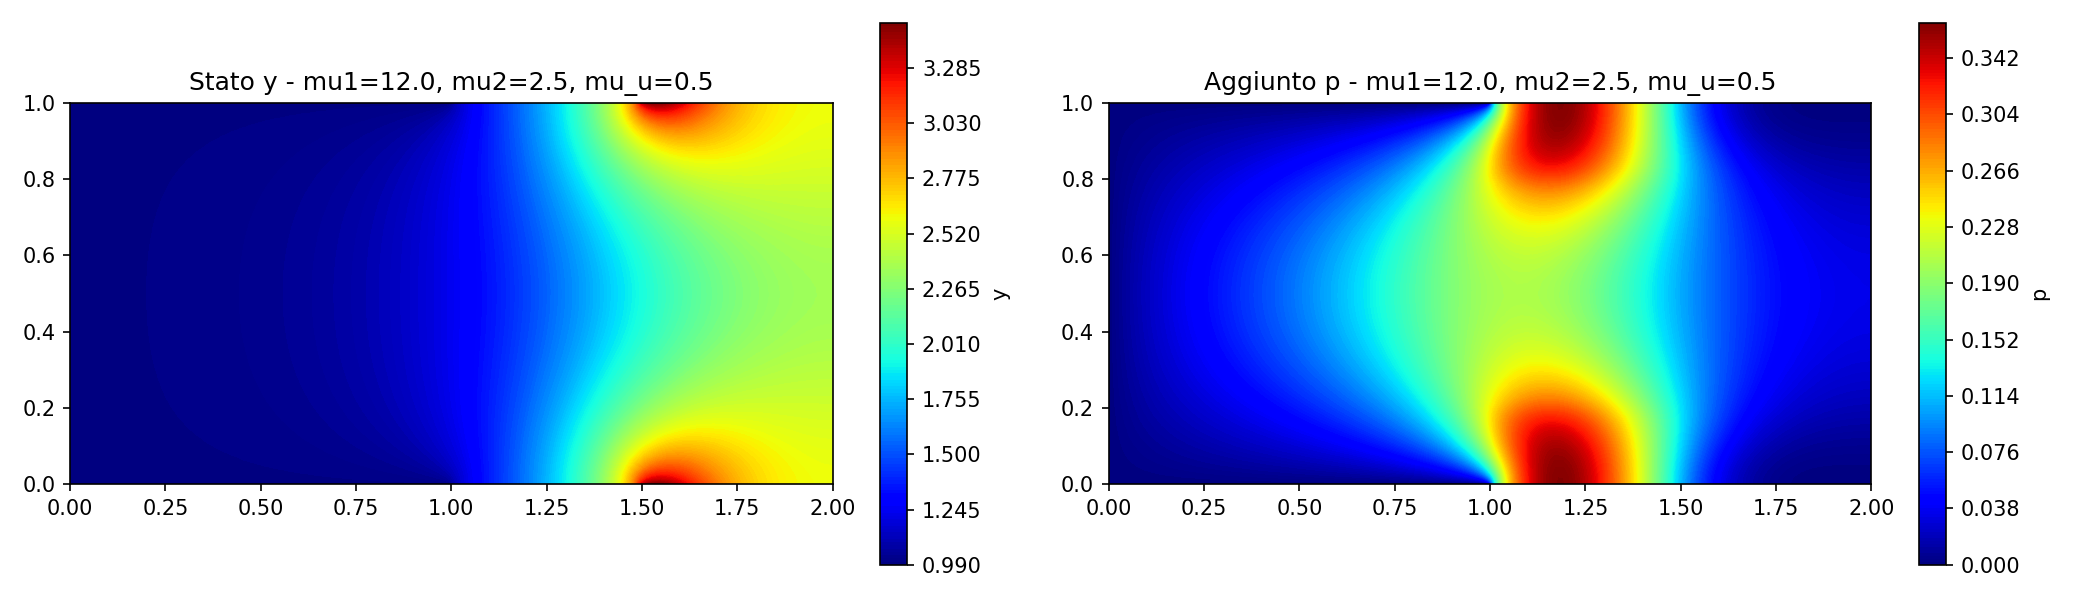

In [3]:
!python -m src.full_order.run_single_solve \
    --config {CONFIG_PATH} \
    --mu1 12 \
    --mu2 2.5 \
    --mu_u 0.5 \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'fom_solution.png'))

### 2.2 Generazione snapshot (training + test)

Campiona `mu1`, `mu2`, `mu_u` uniformemente sui range definiti nel config e risolve il FOM per ciascun campione. L'assembly indipendente da mu viene fatto una sola volta; il ciclo aggiorna solo la matrice di controllo e il solve.

Due set separati (seed diversi): uno di **training** (per la POD) e uno di **test** (mai visto durante la POD, per validare il ROM). Se un file esiste gia', **non viene rigenerato** (skip).

Output: un `.npz` per set, con `mu1`, `mu2`, `mu_u`, e le matrici `Y`, `P`, `U` (una colonna per campione).

In [4]:
N_SAMPLES = 300
N_TEST = 150
TEST_SEED = 123  # diverso dal seed di default usato per il training (42)

SNAPSHOTS_PATH = os.path.join(SNAPSHOTS_DIR, f'test1_{N_SAMPLES}.npz')
TEST_SNAPSHOTS_PATH = os.path.join(SNAPSHOTS_DIR, f'test1_test{N_TEST}.npz')

if os.path.exists(SNAPSHOTS_PATH):
    print(f"Training set gia' presente: {SNAPSHOTS_PATH} (skip)")
else:
    !python -m src.full_order.generate_snapshots \
        --config {CONFIG_PATH} \
        --n-samples {N_SAMPLES} \
        --output {SNAPSHOTS_PATH}

if os.path.exists(TEST_SNAPSHOTS_PATH):
    print(f"Test set gia' presente: {TEST_SNAPSHOTS_PATH} (skip)")
else:
    !python -m src.full_order.generate_snapshots \
        --config {CONFIG_PATH} \
        --n-samples {N_TEST} \
        --seed {TEST_SEED} \
        --output {TEST_SNAPSHOTS_PATH}

Training set gia' presente: data/snapshots/test1_300.npz (skip)
Test set gia' presente: data/snapshots/test1_test150.npz (skip)


In [5]:
import numpy as np

data = np.load(SNAPSHOTS_PATH)
print('Training - chiavi:', list(data.keys()), ' Y shape:', data['Y'].shape)

test_data = np.load(TEST_SNAPSHOTS_PATH)
print('Test     - chiavi:', list(test_data.keys()), ' Y shape:', test_data['Y'].shape)

Training - chiavi: ['mu1', 'mu2', 'mu_u', 'Y', 'P', 'U']  Y shape: (5306, 300)
Test     - chiavi: ['mu1', 'mu2', 'mu_u', 'Y', 'P', 'U']  Y shape: (5306, 150)


## 3. ROM (POD)

### 3.1 Stato e aggiunto

Costruisce la base POD per stato e aggiunto a partire dagli snapshot generati sopra. Il numero di modi N e' scelto automaticamente in base a una soglia di energia cumulata (non piu' fisso). Prodotto scalare configurabile qui sotto; `--plot` mostra subito il decadimento degli autovalori (nessun path da gestire).

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Prodotto scalare: seminorm
Caricamento snapshot da data/snapshots/test1_300.npz ...
Y shape: (5306, 300), P shape: (5306, 300)
N scelto: stato=71, aggiunto=19 (indipendenti)
Base POD salvata in data/snapshots/test1_pod.npz
Caricamento test set da data/snapshots/test1_test150.npz per l'errore di ricostruzione ...
Plot salvato in /tmp/pod_eigenvalue_decay.png
PLOT_PATH=/tmp/pod_eigenvalue_decay.png


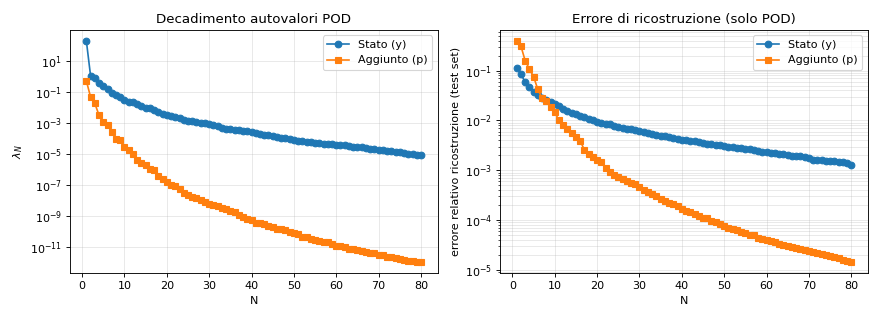

In [ ]:
INNER_PRODUCT = 'seminorm' 
ENERGY_THRESHOLD = 1-1e-6   # N scelto automaticamente in base a questa soglia
NORMALIZE_CORRELATION = True  # divide la matrice di correlazione per M (eq. 17 del paper) 
POD_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_pod.npz')

normalize_flag = '' if NORMALIZE_CORRELATION else '--no-normalize-correlation'

!python -m src.rom.train_pod \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH} \
    --inner-product {INNER_PRODUCT} \
    --energy-threshold {ENERGY_THRESHOLD} \
    {normalize_flag} \
    --output {POD_PATH} \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'pod_eigenvalue_decay.png'))

Sweep del numero di modi N per stato e aggiunto - due script separati:
- `sweep_pod_nn.py` allena una PODNN per ogni N (lento, salva `sweep_n_modes.csv`)
- `sweep_pod_error.py` calcola solo l'errore di sola POD (veloce, nessuna rete) e, se gli passi `--podnn-csv`, genera **lui** il plot combinato leggendo il csv gia' calcolato dallo sweep PODNN (nessun retraining)

Entrambe le celle saltano il lavoro se il csv esiste gia' (cancella il file per rilanciare quella parte):

Sweep PODNN gia' presente: data/snapshots/sweep_n_modes.csv (skip - cancella il file per rilanciarlo)
Sweep solo-POD gia' presente: data/snapshots/sweep_pod_error.csv (skip - cancella il file per rilanciarlo)


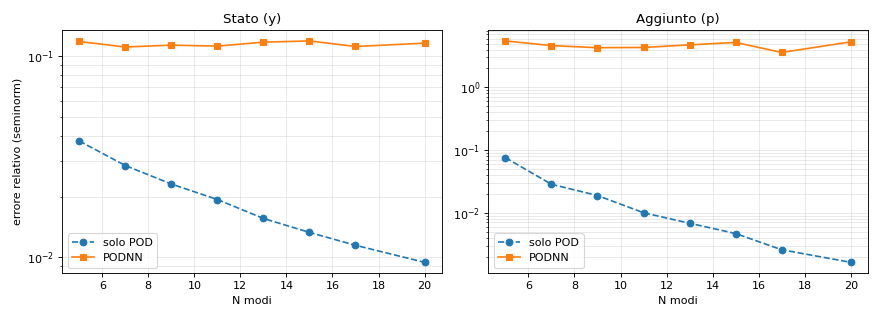

In [7]:
N_MODES_VALUES = '5,7,9,11,13,15,17,20'
HIDDEN_DIM = 32
SWEEP_EPOCHS = 1
SWEEP_N_MODES_OUTPUT = os.path.join(SNAPSHOTS_DIR, 'sweep_n_modes.csv')
SWEEP_POD_ERROR_OUTPUT = os.path.join(SNAPSHOTS_DIR, 'sweep_pod_error.csv')
# sweep PODNN (lento - allena una rete per N) - skip se il csv esiste gia'
if os.path.exists(SWEEP_N_MODES_OUTPUT):
    print(f"Sweep PODNN gia' presente: {SWEEP_N_MODES_OUTPUT} (skip - cancella il file per rilanciarlo)")
else:
    !python -m src.rom.sweep_pod_nn \
        --config {CONFIG_PATH} \
        --snapshots {SNAPSHOTS_PATH} \
        --test-snapshots {TEST_SNAPSHOTS_PATH} \
        --sweep-param n_modes \
        --values {N_MODES_VALUES} \
        --hidden-dim {HIDDEN_DIM} \
        --epochs {SWEEP_EPOCHS} \
        --output {SWEEP_N_MODES_OUTPUT}

# sweep solo POD (veloce, nessuna rete) + plot combinato (letto dal csv PODNN sopra, non rifatto qui) -
# skip se il csv esiste gia'
if os.path.exists(SWEEP_POD_ERROR_OUTPUT):
    print(f"Sweep solo-POD gia' presente: {SWEEP_POD_ERROR_OUTPUT} (skip - cancella il file per rilanciarlo)")
else:
    !python -m src.rom.sweep_pod_error \
        --config {CONFIG_PATH} \
        --snapshots {SNAPSHOTS_PATH} \
        --test-snapshots {TEST_SNAPSHOTS_PATH} \
        --values {N_MODES_VALUES} \
        --podnn-csv {SWEEP_N_MODES_OUTPUT} \
        --output {SWEEP_POD_ERROR_OUTPUT}
from pathlib import Path
from IPython.display import Image
Image(str(Path(SWEEP_POD_ERROR_OUTPUT).with_suffix('.png')))

### 3.2 Controllo (POD)

`u` non e' un campo di dominio come `y` - e' una traccia 1D sul bordo dove il controllo puo' essere attivo, mascherata a zero fuori Gamma_C (per definizione: `u = dy/dn = 0` su Gamma_N). La POD si fa su questa traccia (prodotto scalare euclideo), poi una piccola FFNN impara `mu -> coefficienti proiettati` (pattern PODNN, `Lab9/PODnn.ipynb` del prof).

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento snapshot da data/snapshots/test1_300.npz ...
Estrazione traccia di controllo sul bordo ...
Traccia: 276 nodi di bordo, 300 snapshot
N modi scelto: 15
Caricamento test set da data/snapshots/test1_test150.npz per l'errore di ricostruzione ...
Plot salvato in /tmp/control_pod_eigenvalue_decay.png
PLOT_PATH=/tmp/control_pod_eigenvalue_decay.png
Base POD + coefficienti + mu di training salvati in data/snapshots/test1_control_pod.npz


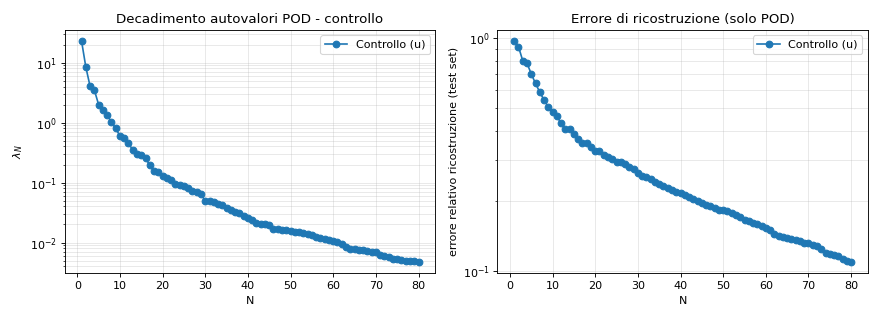

In [8]:
CONTROL_POD_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_control_pod.npz')
CONTROL_ENERGY_THRESHOLD = 1 - 1e-6   # N scelto automaticamente in base a questa soglia
CONTROL_MAX_MODES = 15                 # tetto massimo, anche se la soglia non e' raggiunta
CONTROL_NORMALIZE_CORRELATION = True

control_normalize_flag = '' if CONTROL_NORMALIZE_CORRELATION else '--no-normalize-correlation'

!python -m src.rom.build_control_pod \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH} \
    --energy-threshold {CONTROL_ENERGY_THRESHOLD} \
    --max-modes {CONTROL_MAX_MODES} \
    {control_normalize_flag} \
    --output {CONTROL_POD_PATH} \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'control_pod_eigenvalue_decay.png'))

## 4. GNN

Tre varianti progressive, tutte basate su [gca-rom](https://github.com/fpichi/gca-rom) (libreria non modificata): solo stato `y`, solo aggiunto `p`, poi combinati come due canali della stessa rete. Bypassiamo `pde.problem()`/`gui.hyperparameters_selection()` (pensati per i benchmark del paper originale, con parametri a griglia sintetici) - usiamo i nostri µ1,µ2,µu veri e lo stesso split train/test di POD/PODNN, cosi' il confronto e' diretto.

### 4.0 Setup: repo gca-rom + torch_geometric

Serve una copia locale della repo `gca-rom` (clonata a parte, non nel nostro repo). Aggiorna `GCA_ROM_PATH` sotto.

In [9]:
GCA_ROM_PATH = 'gca-rom'  # <- path alla repo gca-rom clonata (aggiorna se diverso)
GNN_DIR = os.path.join('data', 'gnn')
os.makedirs(GNN_DIR, exist_ok=True)

import importlib.util
if importlib.util.find_spec('torch_geometric') is None:
    !pip install -q torch_geometric

if not os.path.isdir(GCA_ROM_PATH):
    !git clone https://github.com/fpichi/gca-rom.git {GCA_ROM_PATH}
else:
    print(f"{GCA_ROM_PATH} gia' presente (skip clone)")

gca-rom gia' presente (skip clone)


### 4.1 Conversione snapshot -> formato gca-rom

Converte i nostri `.npz` (train e test, stessi usati per POD/PODNN) in `.mat` con coordinate mesh, connettivita' (T, E) e campi. Tre conversioni: solo `y`, solo `p`, combinato (`VX`=y, `VY`=p). Skip se il file esiste gia'.

In [10]:
def convert_if_missing(snapshots_path, output_path, n_comp, field=None):
    if os.path.exists(output_path):
        print(f"{output_path} gia' presente (skip)")
        return
    field_flag = f'--field {field}' if field is not None else ''
    !python -m src.gnn.convert_to_gca_rom \
        --config {CONFIG_PATH} \
        --snapshots {snapshots_path} \
        --n-comp {n_comp} \
        {field_flag} \
        --output {output_path}

TRAIN_Y_MAT = os.path.join(GNN_DIR, 'train_y.mat')
TEST_Y_MAT = os.path.join(GNN_DIR, 'test_y.mat')
TRAIN_P_MAT = os.path.join(GNN_DIR, 'train_p.mat')
TEST_P_MAT = os.path.join(GNN_DIR, 'test_p.mat')
TRAIN_YP_MAT = os.path.join(GNN_DIR, 'train_yp.mat')
TEST_YP_MAT = os.path.join(GNN_DIR, 'test_yp.mat')

convert_if_missing(SNAPSHOTS_PATH, TRAIN_Y_MAT, n_comp=1, field='y')
convert_if_missing(TEST_SNAPSHOTS_PATH, TEST_Y_MAT, n_comp=1, field='y')
convert_if_missing(SNAPSHOTS_PATH, TRAIN_P_MAT, n_comp=1, field='p')
convert_if_missing(TEST_SNAPSHOTS_PATH, TEST_P_MAT, n_comp=1, field='p')
convert_if_missing(SNAPSHOTS_PATH, TRAIN_YP_MAT, n_comp=2)
convert_if_missing(TEST_SNAPSHOTS_PATH, TEST_YP_MAT, n_comp=2)

data/gnn/train_y.mat gia' presente (skip)
data/gnn/test_y.mat gia' presente (skip)
data/gnn/train_p.mat gia' presente (skip)
data/gnn/test_p.mat gia' presente (skip)
data/gnn/train_yp.mat gia' presente (skip)
data/gnn/test_yp.mat gia' presente (skip)


### 4.2 Training: solo y, solo p, combinato

`train_gnn.py` costruisce `HyperParams` a mano (bypassa la GUI di gca-rom) e allena con i nostri µ reali. Iperparametri di default = preset "poisson" di gca-rom (ragionevole punto di partenza per un problema scalare stazionario). Skip se i pesi esistono gia' (cancella la cartella per rilanciare).

In [ ]:
import json
import shutil

GNN_EPOCHS = 5000
GNN_BOTTLENECK = 15
GNN_BATCH_SIZE = None  # None = full-batch (tutto il train set in un colpo solo); es. 32 per mini-batch
GNN_MINIBATCH = False  # True = un optimizer.step() per batch (SGD vera); richiede GNN_BATCH_SIZE impostato
GNN_MODELS_DIR = os.path.join(GNN_DIR, 'models')

# default di train_gnn.py per gli iperparametri che questa cella non espone - usati solo per
# ricostruire train_meta.json di run vecchie (fatte prima che lo scrivessimo), MAI cambiati qui
_TRAIN_GNN_DEFAULTS = {
    'scaling_type': 4, 'scaler_number': 3,
    'ffn': 200, 'map_nodes': 50, 'lambda_map': 10.0, 'in_channels': 2,
}

def train_if_missing(train_mat, test_mat, comp, net_name, field=None):
    net_dir = os.path.join(GNN_MODELS_DIR, net_name)
    meta_path = os.path.join(net_dir, 'train_meta.json')
    weights_path = os.path.join(net_dir, f'{net_name}_standard.pt')  # net_run = '_standard' (scaler_number=3)
    target = {'epochs': GNN_EPOCHS, 'batch_size': GNN_BATCH_SIZE, 'minibatch': GNN_MINIBATCH}

    # skip solo se il training e' arrivato in fondo con QUESTI stessi parametri
    # (train_meta.json viene scritto da train_gnn.py solo a fine training riuscito)
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            meta = json.load(f)
        if all(meta.get(k) == v for k, v in target.items()):
            print(f"{meta_path} gia' presente con parametri identici (skip)")
            return
        print(f"{meta_path} presente ma con parametri diversi (target={target}, trovato={meta}) - ri-allena")
    elif os.path.exists(weights_path):
        # i pesi ci sono ma non il meta: quasi certamente un run fatto prima che train_gnn.py
        # scrivesse train_meta.json (es. crash nella valutazione finale, bug ora corretto) -
        # il training in se' era completo, ricostruiamo il meta invece di ributtare via i pesi
        print(f"{weights_path} presente ma senza train_meta.json - ricostruisco il meta assumendo i "
              "default di train_gnn.py (nessun ri-training)")
        backfilled = {**target, 'comp': comp, 'field': field, 'bottleneck_dim': GNN_BOTTLENECK, **_TRAIN_GNN_DEFAULTS}
        with open(meta_path, 'w') as f:
            json.dump(backfilled, f)
        print(f"{meta_path} scritto - usa la cella di valutazione (4.3) per ricalcolare l'errore")
        return
    elif os.path.exists(net_dir):
        print(f"{net_dir} presente ma senza pesi ne' train_meta.json (run interrotta prima di salvare) - ri-allena")

    if os.path.exists(net_dir):
        shutil.rmtree(net_dir)
    field_flag = f'--field {field}' if field is not None else ''
    batch_flag = f'--batch-size {GNN_BATCH_SIZE}' if GNN_BATCH_SIZE is not None else ''
    minibatch_flag = '--minibatch' if (GNN_BATCH_SIZE is not None and GNN_MINIBATCH) else ''
    !python -m src.gnn.train_gnn \
        --config {CONFIG_PATH} \
        --gca-rom-path {GCA_ROM_PATH} \
        --train-mat {train_mat} \
        --test-mat {test_mat} \
        --comp {comp} \
        {field_flag} \
        --net-name {net_name} \
        --net-dir {net_dir} \
        --bottleneck-dim {GNN_BOTTLENECK} \
        --epochs {GNN_EPOCHS} \
        {batch_flag} \
        {minibatch_flag}

train_if_missing(TRAIN_Y_MAT, TEST_Y_MAT, comp=1, net_name='test1_gnn_y', field='y')
train_if_missing(TRAIN_P_MAT, TEST_P_MAT, comp=1, net_name='test1_gnn_p', field='p')
train_if_missing(TRAIN_YP_MAT, TEST_YP_MAT, comp=2, net_name='test1_gnn_yp')

### 4.3 Valutazione (errore L2/H1 + speedup, senza ri-allenare)

`evaluate_gnn.py` ricostruisce la rete dagli iperparametri salvati in `train_meta.json` e carica i pesi gia' allenati - utile per rivalutare o confrontare varianti (es. batch size diversi) senza rilanciare il training.

In [ ]:
def evaluate(train_mat, test_mat, net_name):
    net_dir = os.path.join(GNN_MODELS_DIR, net_name)
    !python -m src.gnn.evaluate_gnn \
        --config {CONFIG_PATH} \
        --gca-rom-path {GCA_ROM_PATH} \
        --train-mat {train_mat} \
        --test-mat {test_mat} \
        --net-dir {net_dir}

evaluate(TRAIN_Y_MAT, TEST_Y_MAT, 'test1_gnn_y')
evaluate(TRAIN_P_MAT, TEST_P_MAT, 'test1_gnn_p')
evaluate(TRAIN_YP_MAT, TEST_YP_MAT, 'test1_gnn_yp')

### 4.4 Valutazione su un singolo punto (mu1, mu2, mu_u)

Invece della media su tutto il test set, risolve il FOM per una sola terna di parametri e confronta con la predizione GNN in quel punto (utile per ispezionare un caso specifico, come la cella 2.1 ma con la GNN).

In [ ]:
NET_NAME = 'test1_gnn_yp'          # 'test1_gnn_y' | 'test1_gnn_p' | 'test1_gnn_yp'
TRAIN_MAT = TRAIN_YP_MAT           # usa TRAIN_Y_MAT o TRAIN_P_MAT per gli altri due
MU1 = 12
MU2 = 2.5
MU_U = 0.5

NET_DIR = os.path.join(GNN_MODELS_DIR, NET_NAME)

!python -m src.gnn.evaluate_gnn_single \
    --config {CONFIG_PATH} \
    --gca-rom-path {GCA_ROM_PATH} \
    --train-mat {TRAIN_MAT} \
    --net-dir {NET_DIR} \
    --mu1 {MU1} \
    --mu2 {MU2} \
    --mu_u {MU_U}

## 5. Autoencoder

*(da aggiungere)*

In [12]:
!pwd
!ls src/
!ls src/gnn/


/content/vbOCP
dl  full_order	gnn  __pycache__  rom  utils.py
convert_to_gca_rom.py  __pycache__  train_gnn.py
